# IMPORTANT
For parallel processing, In functions, if we send whole state for everynode, then it will be pointing to same things - 
``` 
return state
```
Instead of this we return the dictionry that is actually updated in the function
```
return {'bpd':bpd}
```

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

c:\Users\paliw\OneDrive\Documents\Self_study_skill\LangGraph\LG_CampusX\ven2\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [3]:
class Score_set(TypedDict):
    run: int
    six: int
    four: int
    ball: int

    bpd: float
    run_percent: float
    summary: str

In [ ]:
def BPD(state: Score_set):
    bpd = (state['six'] + state['four'])/state['ball']
    
    return {'bpd':bpd}

In [24]:
def run_percentage(state: Score_set):
    run_per = (((state['six']*6)+(state['four']*4))/state['run'])*100

    
    return {'run_percent':run_per}
    

In [ ]:
def summary(state: Score_set):
    summary= f''' The Summary of the data is :\n
     The BPD score is {state['bpd']}\n
 The percentage of Run that crossed the border is {state['run_percent']}'''
    
    
    return {'summary':summary}

In [32]:
graph = StateGraph(Score_set)

graph.add_node('BPD',BPD)
graph.add_node('run_percentage',run_percentage)
graph.add_node('summary',summary)

graph.add_edge(START, 'BPD')
graph.add_edge(START, 'run_percentage')

graph.add_edge('BPD', 'summary')
graph.add_edge('run_percentage', 'summary')

graph.add_edge('summary', END)



workflow = graph.compile()

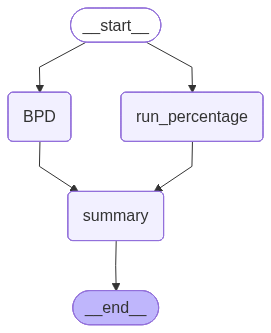

In [27]:
workflow

In [33]:
initial_state = {'run':234,'six':5,'four':6, 'ball': 250}

final_state = workflow.invoke(initial_state)

print(final_state)



{'run': 234, 'six': 5, 'four': 6, 'ball': 250, 'bpd': 0.044, 'run_percent': 23.076923076923077, 'summary': ' The Summary of the data is :\n\n#     The BPD score is 0.044\n\n# The percentage of Run that crossed the border is 23.076923076923077'}


In [34]:
final_state['bpd']

0.044

In [35]:
final_state['summary']

' The Summary of the data is :\n\n#     The BPD score is 0.044\n\n# The percentage of Run that crossed the border is 23.076923076923077'